# Unsupervised Learning Model and Metrics

wanted to use spectral clustering or affinity propagation, but both always kill the kernel & I haven't found a way around it

In [1]:
from util.met_cleaning import clean_met_data
from util.preprocessing import unsupervised_preprocessing, unsupervised_feature_importance
from sklearn.cluster import KMeans, HDBSCAN
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from collections import Counter
import numpy as np
import pandas as pd
import gc

In [2]:
df = clean_met_data()

In [3]:
X = unsupervised_preprocessing(df)

## PCA & Feature Importance

In [4]:
pca = PCA(n_components=2).fit(X)
features_pca = pca.transform(X)

In [5]:
importance_df = unsupervised_feature_importance(pca)
importance_df

,feature,importance
0,access_year,0.130
1,age,0.118
2,title,0.113
3,artist_display_name,0.109
4,object_name,0.107
5,medium,0.107
6,artist_nationality,0.100
7,department,0.100
8,country_mapped,0.081
9,culture,0.067


Text(0.5, 1.0, 'Feature Importance After PCA (Cluster-Driven)')

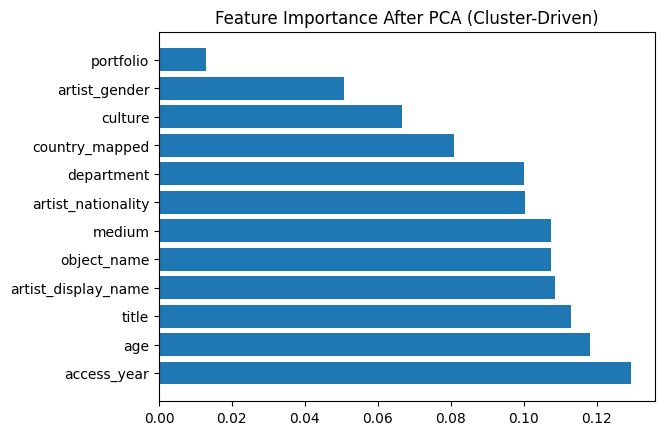

In [6]:
plt.barh(width=importance_df['importance'], y=importance_df['feature'])
plt.title("Feature Importance After PCA (Cluster-Driven)")

## K-Means Clustering

In [7]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto").fit_predict(X)

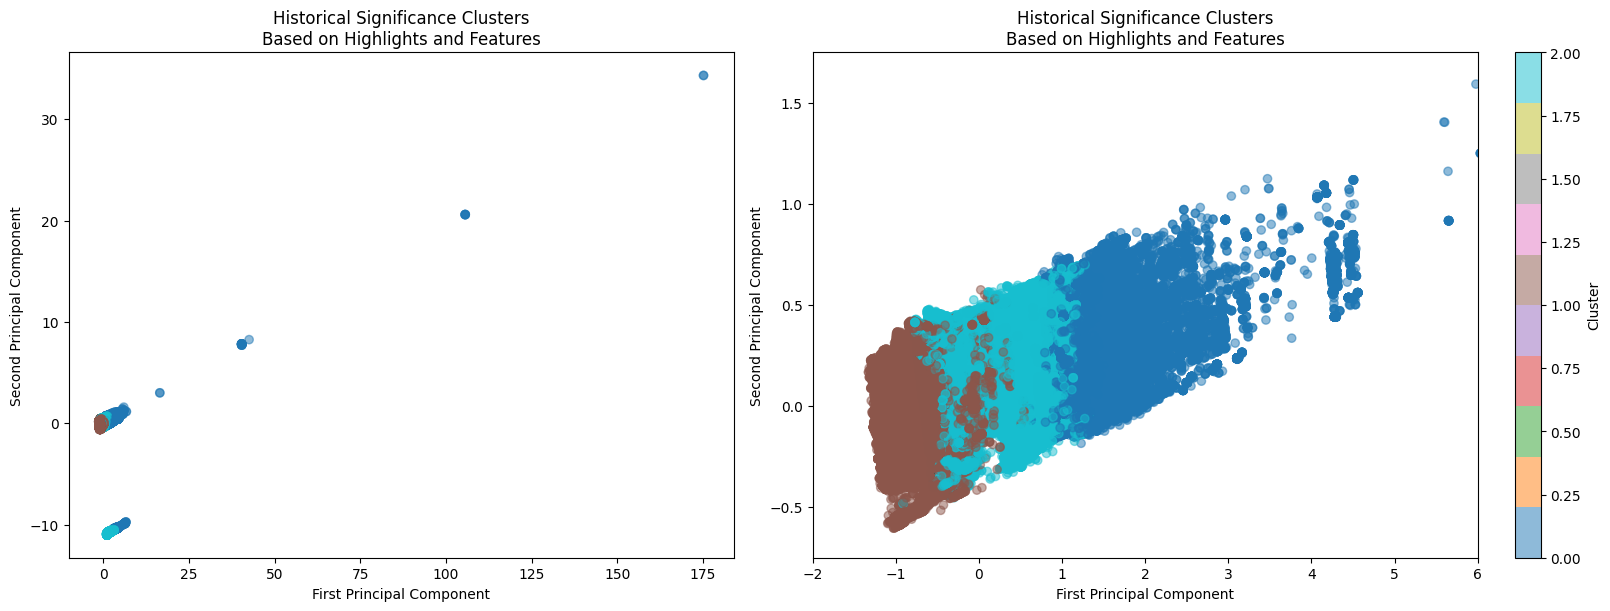

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# First plot
scatter1 = ax1.scatter(features_pca[:, 0], features_pca[:, 1], 
                       c=kmeans, cmap='tab10', alpha=0.5)
ax1.set_title('Historical Significance Clusters\nBased on Highlights and Features')
ax1.set_xlabel('First Principal Component')
ax1.set_ylabel('Second Principal Component')
# cbar1 = fig.colorbar(scatter1, ax=ax1, label='Cluster')

# Second plot
scatter2 = ax2.scatter(features_pca[:, 0], features_pca[:, 1], 
                       c=kmeans, cmap='tab10', alpha=0.5)
ax2.set_title('Historical Significance Clusters\nBased on Highlights and Features')
ax2.set_xlabel('First Principal Component')
ax2.set_ylabel('Second Principal Component')
ax2.set_xlim([-2, 6])
ax2.set_ylim([-0.75, 1.75])
cbar2 = fig.colorbar(scatter2, ax=ax2, label='Cluster')

plt.show()

In [9]:
df['significance_cluster_kmeans'] = kmeans
print("\n K-Means Cluster Analysis:")
for cluster in range(n_clusters):
    cluster_items = df[df['significance_cluster_kmeans'] == cluster]
    print(f"\nCluster {cluster} ({len(cluster_items)} items):")
    no_sig = len(cluster_items[cluster_items['is_significant']])
    print(f"Number of significant artworks: {no_sig}")  
    print(f"Percentage of significant artworks: {np.round(no_sig/len(cluster_items)*100,2)}%")  
    print(f"Average age: {cluster_items['age'].mean():.1f} years")
    countries = cluster_items['country_mapped'].value_counts().head(3)
    print("Top countries:", ', '.join([f"{c} ({n})" for c, n in countries.items() if pd.notna(c)]))
    # cultures = cluster_items['culture'].value_counts().head(3)
    # print("Top cultures:", ', '.join([f"{c} ({n})" for c, n in cultures.items() if pd.notna(c)]))
    mediums = cluster_items['medium'].value_counts().head(3)
    print("Top mediums:", ', '.join([f"{c} ({n})" for c, n in mediums.items() if pd.notna(c)]))


 K-Means Cluster Analysis:

Cluster 0 (73480 items):
Number of significant artworks: 1386
Percentage of significant artworks: 1.89%
Average age: 3167.0 years
Top countries: Egypt (30908), Greece (22071), Cyprus (2959)
Top mediums: Terracotta (23161), Faience (4910), Glass (3983)

Cluster 1 (227646 items):
Number of significant artworks: 2755
Percentage of significant artworks: 1.21%
Average age: 201.6 years
Top countries: United States (83197), France (39797), United Kingdom (24608)
Top mediums: Commercial color lithograph (18155), Etching (17237), Engraving (11691)

Cluster 2 (183830 items):
Number of significant artworks: 5244
Percentage of significant artworks: 2.85%
Average age: 386.7 years
Top countries: United States (31470), France (25142), Japan (22917)
Top mediums: Silk (7586), silk (4673), Silver (3957)


In [10]:
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto").fit_predict(X)

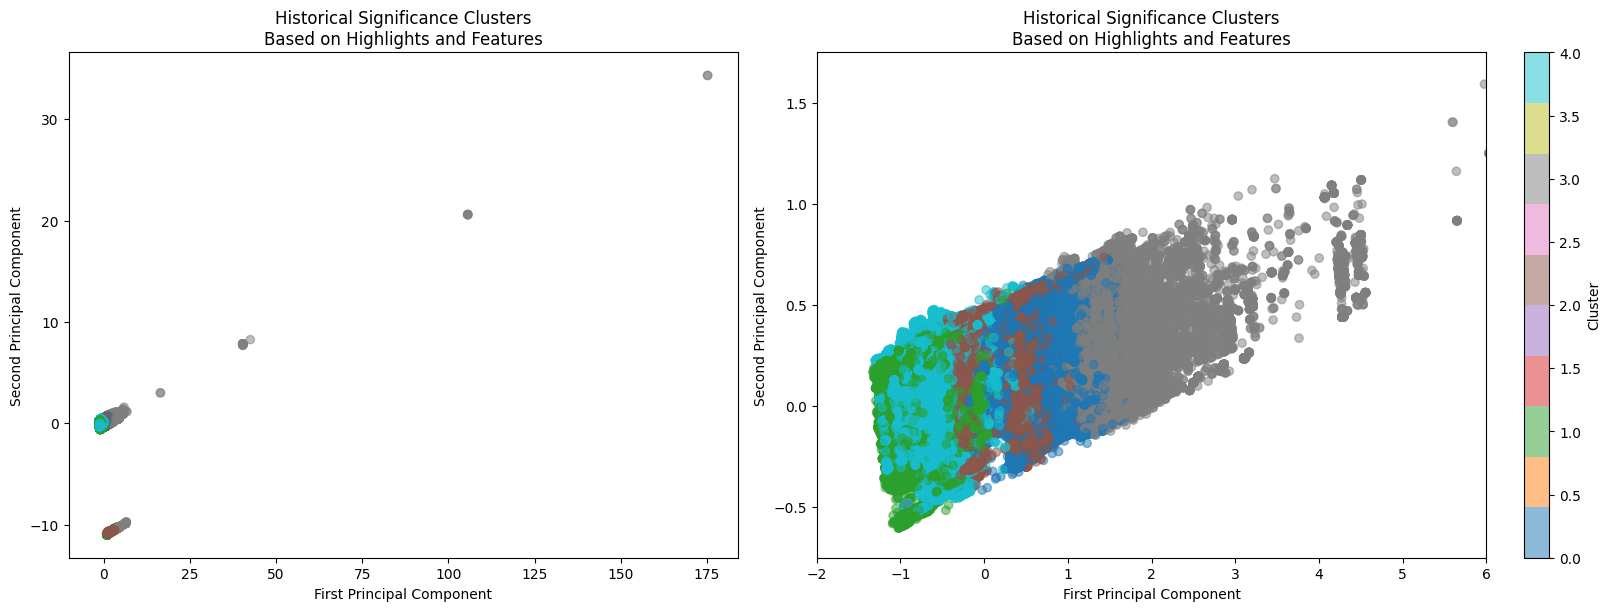

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# First plot
scatter1 = ax1.scatter(features_pca[:, 0], features_pca[:, 1], 
                       c=kmeans, cmap='tab10', alpha=0.5)
ax1.set_title('Historical Significance Clusters\nBased on Highlights and Features')
ax1.set_xlabel('First Principal Component')
ax1.set_ylabel('Second Principal Component')
# cbar1 = fig.colorbar(scatter1, ax=ax1, label='Cluster')

# Second plot
scatter2 = ax2.scatter(features_pca[:, 0], features_pca[:, 1], 
                       c=kmeans, cmap='tab10', alpha=0.5)
ax2.set_title('Historical Significance Clusters\nBased on Highlights and Features')
ax2.set_xlabel('First Principal Component')
ax2.set_ylabel('Second Principal Component')
ax2.set_xlim([-2, 6])
ax2.set_ylim([-0.75, 1.75])
cbar2 = fig.colorbar(scatter2, ax=ax2, label='Cluster')

plt.show()

In [12]:
df['significance_cluster_kmeans'] = kmeans
print("\n K-Means Cluster Analysis:")
for cluster in range(n_clusters):
    cluster_items = df[df['significance_cluster_kmeans'] == cluster]
    print(f"\nCluster {cluster} ({len(cluster_items)} items):")
    no_sig = len(cluster_items[cluster_items['is_significant']])
    print(f"Number of significant artworks: {no_sig}")  
    print(f"Percentage of significant artworks: {np.round(no_sig/len(cluster_items)*100,2)}%")  
    print(f"Average age: {cluster_items['age'].mean():.1f} years")
    countries = cluster_items['country_mapped'].value_counts().head(3)
    print("Top countries:", ', '.join([f"{c} ({n})" for c, n in countries.items() if pd.notna(c)]))
    # cultures = cluster_items['culture'].value_counts().head(3)
    # print("Top cultures:", ', '.join([f"{c} ({n})" for c, n in cultures.items() if pd.notna(c)]))
    mediums = cluster_items['medium'].value_counts().head(3)
    print("Top mediums:", ', '.join([f"{c} ({n})" for c, n in mediums.items() if pd.notna(c)]))


 K-Means Cluster Analysis:

Cluster 0 (49604 items):
Number of significant artworks: 1726
Percentage of significant artworks: 3.48%
Average age: 964.7 years
Top countries: Iran (7482), Egypt (5465), Peru (3328)
Top mediums: Glass (2767), Commercial color photolithograph (2112), Commercial photolithograph (1667)

Cluster 1 (96390 items):
Number of significant artworks: 1051
Percentage of significant artworks: 1.09%
Average age: 226.8 years
Top countries: France (27545), United States (22593), United Kingdom (14081)
Top mediums: Etching (9006), Engraving (7237), Commercial color lithograph (5860)

Cluster 2 (120664 items):
Number of significant artworks: 2586
Percentage of significant artworks: 2.14%
Average age: 363.9 years
Top countries: Japan (22570), France (19044), China (15706)
Top mediums: Silk (6889), Bronze (2824), Woodblock print; ink and color on paper (2413)

Cluster 3 (61621 items):
Number of significant artworks: 971
Percentage of significant artworks: 1.58%
Average age: 3

In [13]:
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto").fit_predict(X)

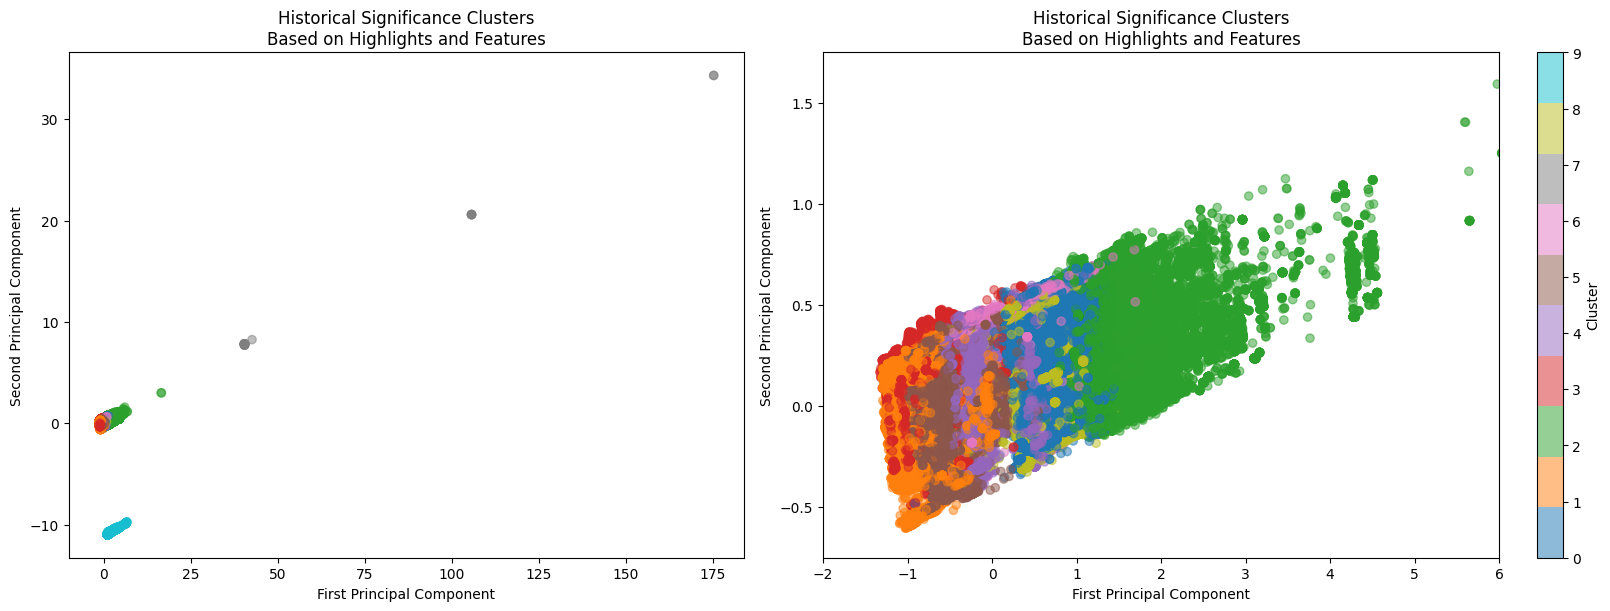

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# First plot
scatter1 = ax1.scatter(features_pca[:, 0], features_pca[:, 1], 
                       c=kmeans, cmap='tab10', alpha=0.5)
ax1.set_title('Historical Significance Clusters\nBased on Highlights and Features')
ax1.set_xlabel('First Principal Component')
ax1.set_ylabel('Second Principal Component')
# cbar1 = fig.colorbar(scatter1, ax=ax1, label='Cluster')

# Second plot
scatter2 = ax2.scatter(features_pca[:, 0], features_pca[:, 1], 
                       c=kmeans, cmap='tab10', alpha=0.5)
ax2.set_title('Historical Significance Clusters\nBased on Highlights and Features')
ax2.set_xlabel('First Principal Component')
ax2.set_ylabel('Second Principal Component')
ax2.set_xlim([-2, 6])
ax2.set_ylim([-0.75, 1.75])
cbar2 = fig.colorbar(scatter2, ax=ax2, label='Cluster')

plt.show()

In [15]:
df['significance_cluster_kmeans'] = kmeans
print("\n K-Means Cluster Analysis:")
for cluster in range(n_clusters):
    cluster_items = df[df['significance_cluster_kmeans'] == cluster]
    print(f"\nCluster {cluster} ({len(cluster_items)} items):")
    no_sig = len(cluster_items[cluster_items['is_significant']])
    print(f"Number of significant artworks: {no_sig}")  
    print(f"Percentage of significant artworks: {np.round(no_sig/len(cluster_items)*100,2)}%")  
    print(f"Average age: {cluster_items['age'].mean():.1f} years")
    countries = cluster_items['country_mapped'].value_counts().head(3)
    print("Top countries:", ', '.join([f"{c} ({n})" for c, n in countries.items() if pd.notna(c)]))
    # cultures = cluster_items['culture'].value_counts().head(3)
    # print("Top cultures:", ', '.join([f"{c} ({n})" for c, n in cultures.items() if pd.notna(c)]))
    mediums = cluster_items['medium'].value_counts().head(3)
    print("Top mediums:", ', '.join([f"{c} ({n})" for c, n in mediums.items() if pd.notna(c)]))


 K-Means Cluster Analysis:

Cluster 0 (61282 items):
Number of significant artworks: 1646
Percentage of significant artworks: 2.69%
Average age: 521.2 years
Top countries: United States (12638), France (5568), Japan (5456)
Top mediums: silk (2002), cotton (1781), Steel (1585)

Cluster 1 (88656 items):
Number of significant artworks: 721
Percentage of significant artworks: 0.81%
Average age: 230.7 years
Top countries: France (23944), United States (22358), United Kingdom (12885)
Top mediums: Etching (8862), Engraving (7219), Commercial color lithograph (5860)

Cluster 2 (66710 items):
Number of significant artworks: 1254
Percentage of significant artworks: 1.88%
Average age: 3212.7 years
Top countries: Egypt (27416), Greece (22028), Cyprus (2957)
Top mediums: Terracotta (23065), Faience (4774), Glass (3724)

Cluster 3 (77993 items):
Number of significant artworks: 1289
Percentage of significant artworks: 1.65%
Average age: 112.1 years
Top countries: United States (77847), United Kingdo

## DBSCAN Clustering

In [16]:
# gc.collect()

In [18]:
dbscan = HDBSCAN(min_samples=10000, n_jobs=-1, leaf_size=1000).fit_predict(features_pca)

: 

In [ ]:
df['significance_cluster_dbscan'] = dbscan

In [ ]:
print("\n DBSCAN Cluster Analysis:")
for cluster in range(n_clusters):
    cluster_items = df[df['significance_cluster_dbscan'] == cluster]
    print(f"\nCluster {cluster} ({len(cluster_items)} items):")
    print(f"Number of significant artworks: {len(cluster_items[cluster_items['is_significant'] == True])}")  # noqa: E712
    print(f"Average age: {cluster_items['age'].mean():.1f} years")
    countries = cluster_items['country_mapped'].value_counts().head(3)
    print("Top countries:", ', '.join([f"{c} ({n})" for c, n in countries.items() if pd.notna(c)]))
    cultures = cluster_items['culture'].value_counts().head(3)
    print("Top cultures:", ', '.join([f"{c} ({n})" for c, n in cultures.items() if pd.notna(c)]))
    mediums = cluster_items['medium'].value_counts().head(3)
    print("Top mediums:", ', '.join([f"{c} ({n})" for c, n in mediums.items() if pd.notna(c)]))


 DBSCAN Cluster Analysis:


KeyError: 'significance_cluster_dbscan'

## Hyperparameter tuning for DBSCAN 
to explore different groupings given various PCA dimensions and epsilon values

In [ ]:


for n in [2,3,4,5,6,7,8,9,10]:
    for e in [0.75, 1, 1.25, 1.5, 1.75, 2]:
        
        pca = PCA(n_components=n).fit_transform(X)
        df['significance_cluster_dbscan'] = DBSCAN(eps=e).fit_predict(pca)

        print("DBSCAN Cluster Analysis:")
        print(f"Number of Components: {n}, Epsilon: {e}")
        for cluster in range(n_clusters):
            cluster_items = df[df['significance_cluster_dbscan'] == cluster]
            print(f"\nCluster {cluster} ({len(cluster_items)} items):")
            print(f"Number of significant artworks: {len(cluster_items[cluster_items['is_significant'] == True])}")  # noqa: E712
            print(f"Average age: {cluster_items['age'].mean():.1f} years")
            countries = cluster_items['country_mapped'].value_counts().head(3)
            print("Top countries:", ', '.join([f"{c} ({n})" for c, n in countries.items() if pd.notna(c)]))
            cultures = cluster_items['culture'].value_counts().head(3)
            print("Top cultures:", ', '.join([f"{c} ({n})" for c, n in cultures.items() if pd.notna(c)]))
            mediums = cluster_items['medium'].value_counts().head(3)
            print("Top mediums:", ', '.join([f"{c} ({n})" for c, n in mediums.items() if pd.notna(c)]))


 DBSCAN Cluster Analysis:
Number of Components: 2, Epsilon: 0.75

Cluster 0 (7 items):
Number of significant artworks: 1
Average age: 172.0 years
Top countries: United States (4), United Kingdom (1), France (1)
Top cultures: American (2), probably American (1), Scottish (1)
Top mediums: silk (3), Gold (1), wool (1)

Cluster 1 (9 items):
Number of significant artworks: 0
Average age: 124.0 years
Top countries: United States (4), United Kingdom (1), France (1)
Top cultures: American (2), British (1), Tibetan (1)
Top mediums: Gold (2), Silk, cyanotype printing of portrait, printed (1), silk, china (1)

Cluster 2 (13 items):
Number of significant artworks: 0
Average age: 116.0 years
Top countries: United States (3), France (2), United Kingdom (1)
Top cultures: American (1)
Top mediums: Gold (7), Watercolor and graphite on paper (2), (a, b) linen; (c, d) cotton (1)

 DBSCAN Cluster Analysis:
Number of Components: 2, Epsilon: 1

Cluster 0 (271522 items):
Number of significant artworks: 3506

KeyboardInterrupt: 